# Generate Predictions Images for a Site over Time
This notebook is used to generate predictions overlays for a given location.

Outputs are saved pngs where prediction score controls the opacity of a single-color image. The script also generates RGB patches for each prediction as well.

In [1]:
import os
import sys

import cv2
import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np
from tensorflow import keras
from tqdm import tqdm

sys.path.append('../')
from scripts.get_s2_data_ee import get_history, get_history_polygon, get_pixel_vectors

%load_ext autoreload
%autoreload 2

In [2]:
# Sentinel 2 band descriptions
band_descriptions = {
    'B1': 'Aerosols, 442nm',
    'B2': 'Blue, 492nm',
    'B3': 'Green, 559nm',
    'B4': 'Red, 665nm',
    'B5': 'Red Edge 1, 704nm',
    'B6': 'Red Edge 2, 739nm',
    'B7': 'Red Edge 3, 779nm',
    'B8': 'NIR, 833nm',
    'B8A': 'Red Edge 4, 864nm',
    'B9': 'Water Vapor, 943nm',
    'B11': 'SWIR 1, 1610nm',
    'B12': 'SWIR 2, 2186nm'
}

In [106]:
# Enter rect width in degrees (0.035 max recommended) and site coordinates
rect_width = 0.0055
site_coords = [115.350242, -8.562121]
name = 'temesi'

In [107]:
patch_history = get_history([site_coords], 
                            [name], 
                            rect_width,
                            num_months = 58,
                            start_date = '2016-03-01')

  0%|          | 0/58 [00:00<?, ?it/s]

  2%|▏         | 1/58 [00:02<02:04,  2.19s/it]

  3%|▎         | 2/58 [00:03<01:50,  1.97s/it]

  5%|▌         | 3/58 [00:06<02:05,  2.29s/it]

  7%|▋         | 4/58 [00:08<01:53,  2.11s/it]

...

 93%|█████████▎| 54/58 [02:07<00:09,  2.43s/it]

 95%|█████████▍| 55/58 [02:09<00:07,  2.35s/it]

 97%|█████████▋| 56/58 [02:11<00:04,  2.31s/it]

 98%|█████████▊| 57/58 [02:13<00:02,  2.21s/it]

100%|██████████| 58/58 [02:16<00:00,  2.35s/it]


## Generate Predictions

In [108]:
# Select model to load for predictions
model = keras.models.load_model('../models/65_mo_tpa_bootstrap_toa-12-20-2020.h5')

In [109]:
def normalize(array):
    return np.array(array) / 3000

def predict_time_series(patch_histories, site_name, model):
    rgb_stack = []
    preds_stack = []
    dates_list = []
    
    dates = list(patch_histories.keys())
    for date in tqdm(dates):
        rgb = np.stack((patch_histories[date][site_name]['B4'],
                        patch_histories[date][site_name]['B3'],
                        patch_histories[date][site_name]['B2']), axis=-1)
        
        width, height = rgb.shape[:2]
        pixel_vectors = []
        for i in range(width):
            for j in range(height):
                pixel_vector = []
                band_lengths = [len(patch_history[date][site_name][band]) for band in band_descriptions]
                if np.array(band_lengths).all() > 0:
                    for band in band_descriptions:
                        pixel_vector.append(patch_histories[date][site_name][band][i][j])
                    pixel_vectors.append(pixel_vector)
        
        pixel_vectors = normalize(pixel_vectors)
        if len(pixel_vectors) > 0 and np.median(rgb) > 0.1:
            rgb_stack.append(rgb / 3000)
            preds = model.predict(np.expand_dims(pixel_vectors, axis=-1))
            preds_img = np.reshape(preds, (width, height, 2))[:,:,1]
            preds_stack.append(preds_img)
            dates_list.append(date)
            
    return np.array(rgb_stack), np.array(preds_stack), dates_list

In [110]:
rgb_stack, preds_stack, dates_list = predict_time_series(patch_history, 'temesi', model)

100%|██████████| 58/58 [00:09<00:00,  6.08it/s]


In [111]:
def green_blue_swap(image):
    # to play nicely with OpenCV's BGR color order
    r,g,b = cv2.split(image)
    image[:,:,0] = b
    image[:,:,1] = g
    image[:,:,2] = r
    return image

In [112]:
def filter_small_points(image):
    # This is experimental. Filter out "hot pixel" predictions
    se1 = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7))
    se2 = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
    mask = cv2.morphologyEx(image, cv2.MORPH_CLOSE, se1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, se2)
    out = image * mask
    return out

In [113]:
def stretch_histogram(array, min_val, max_val):
    clipped = np.clip(array, min_val, max_val)
    stretched = (clipped - min_val) / (max_val - min_val)
    return stretched

### Evaluate histogram clipping, stretching, and gamma parameters

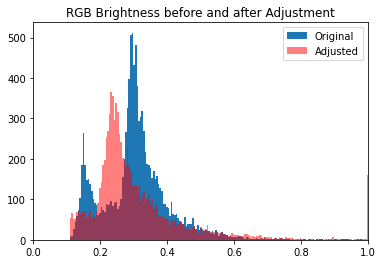

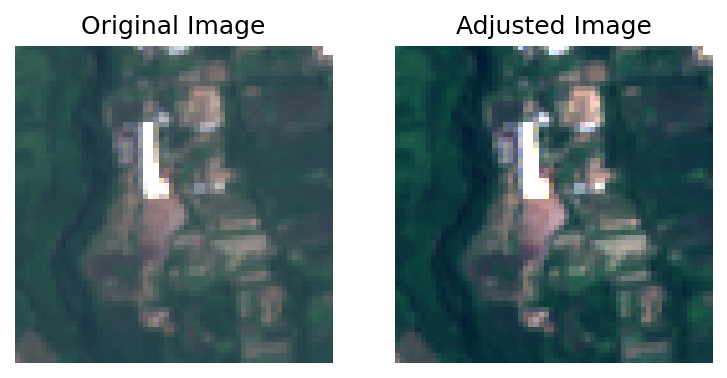

In [114]:
min_val = 0.1
max_val = 0.75
gamma = 1.2

original_image = rgb_stack[0]

edges, bins, patches = plt.hist(original_image.flatten(), 
                                bins=500, 
                                label='Original')

adjusted_image = stretch_histogram(original_image, min_val, max_val) ** gamma
plt.hist((adjusted_image).flatten(), 
         bins=bins, 
         alpha=0.5, 
         color='r',
         label='Adjusted')

plt.xlim([0, 1])
plt.legend()
plt.title('RGB Brightness before and after Adjustment')
plt.show()

plt.figure(dpi=150)
plt.subplot(1,2,1)
plt.imshow(np.clip(original_image, 0, 1), vmin=0, vmax=1)
plt.title('Original Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(adjusted_image, vmin=0, vmax=1)
plt.title('Adjusted Image')
plt.axis('off')
plt.show()

### Save Images

In [14]:
threshold = 0.8
data_dir = os.path.join('figures/time_series/', name)
if not os.path.exists(data_dir):
    os.mkdir(data_dir)


for i, month in enumerate(dates_list):
    rgb_img = (stretch_histogram(rgb_stack[i], min_val, max_val)) ** gamma
    
    # if an image has too much cloud cover, the median rgb color will be low
    if np.median(rgb_img) > 0.1:
        bgr_img = green_blue_swap(rgb_img)
        width, height, channels = np.shape(bgr_img)
        pred_img = preds_stack[i]
        
        # points below threshold are set to black
        pred_img[pred_img < threshold] = 0
        filtered_preds = filter_small_points(pred_img)
        data = np.zeros((width, height, 4))
        
        # Create an array that is fully black. Set opacity to prediction value
        data[:,:,3] = 255 * filtered_preds
        
        cv2.imwrite(os.path.join(data_dir, f'{name}_pred_{month}_{rect_width}.png'), data)
        cv2.imwrite(os.path.join(data_dir, f'{name}_rgb_{month}_{rect_width}.png'), 255 * bgr_img)

## Generate Heatmap Contour

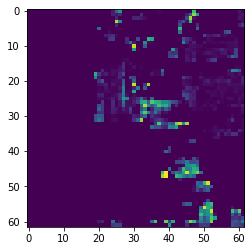

In [332]:
plt.imshow(pred)

In [364]:
len(sorted(contours * scale, key=cv2.contourArea)[-12:])

12

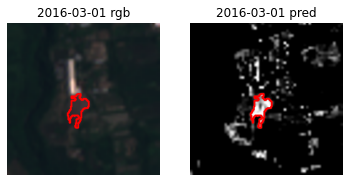

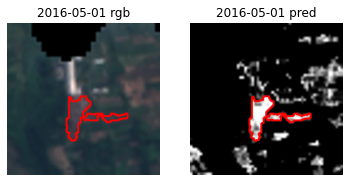

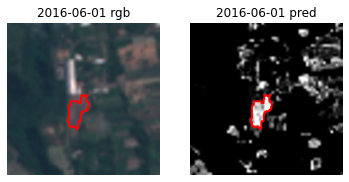

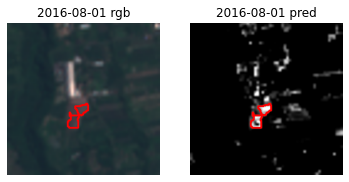

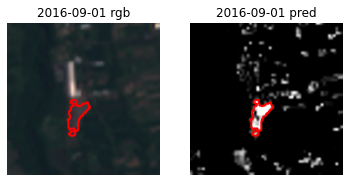

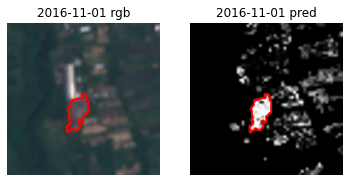

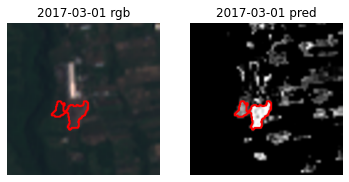

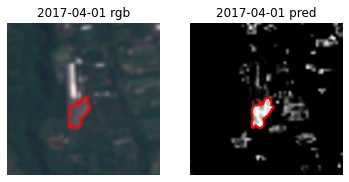

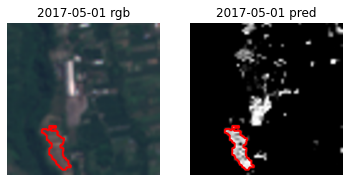

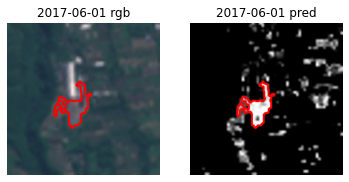

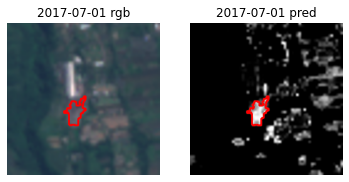

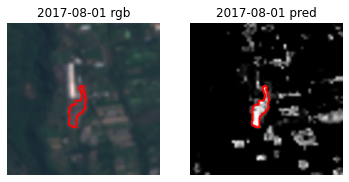

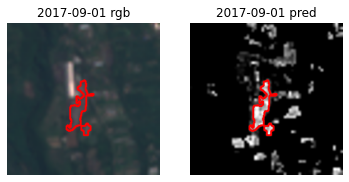

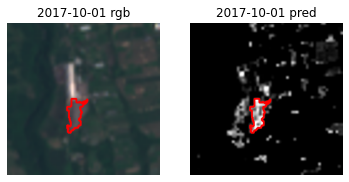

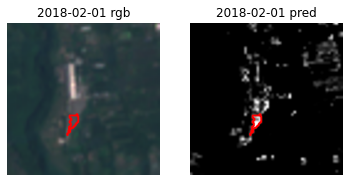

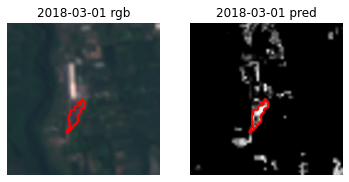

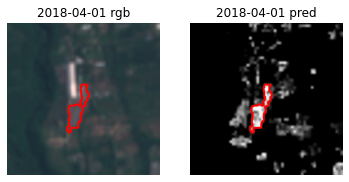

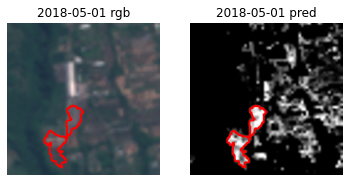

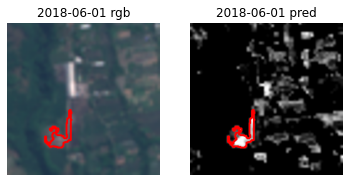

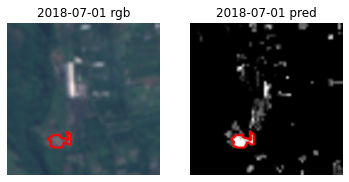

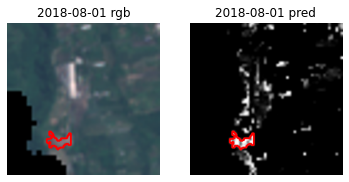

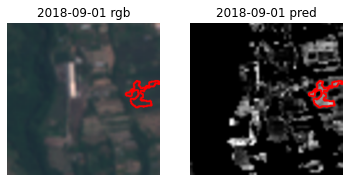

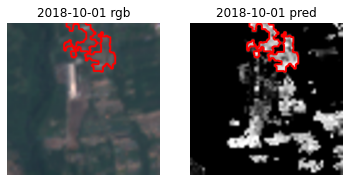

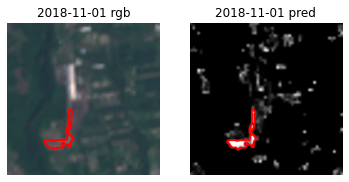

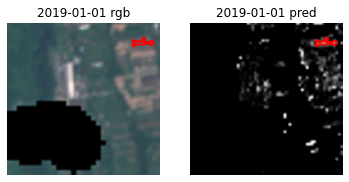

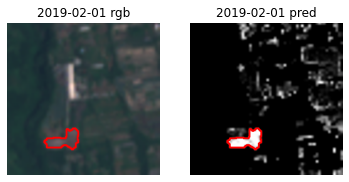

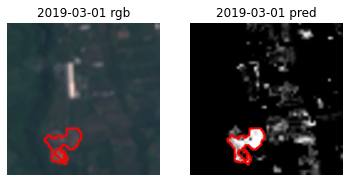

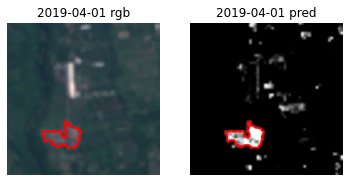

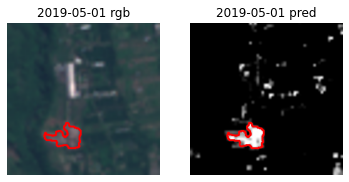

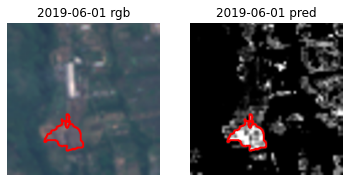

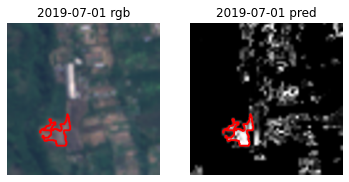

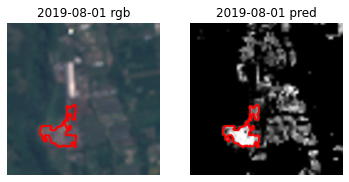

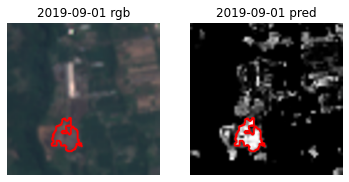

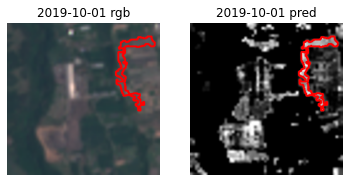

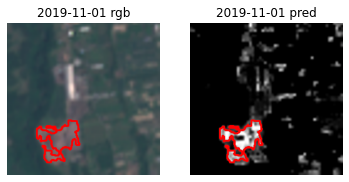

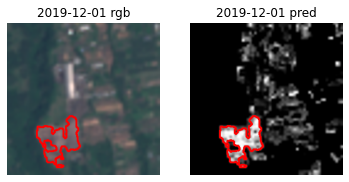

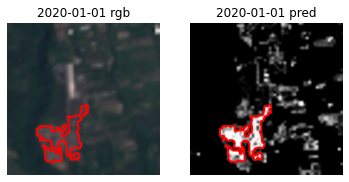

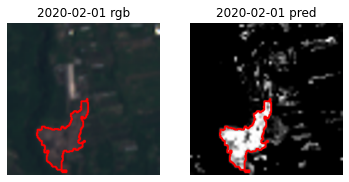

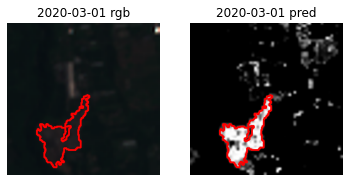

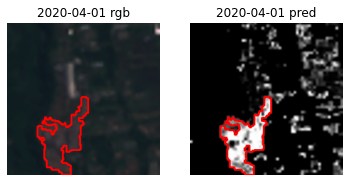

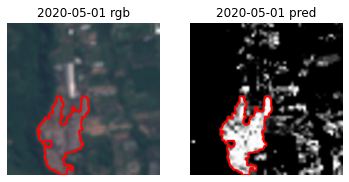

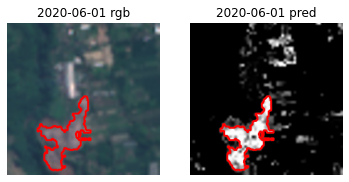

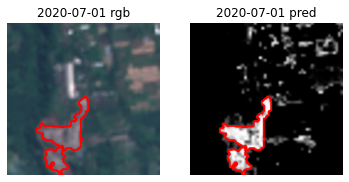

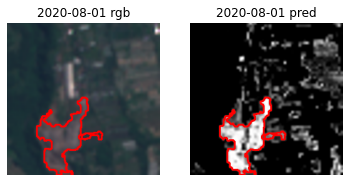

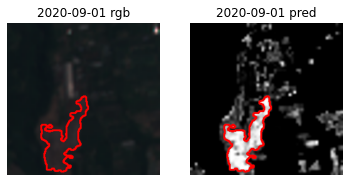

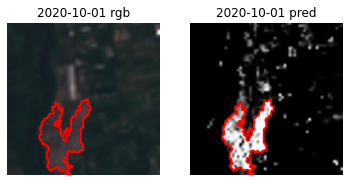

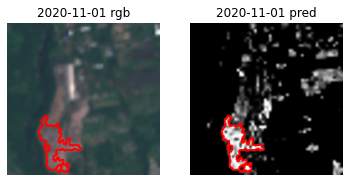

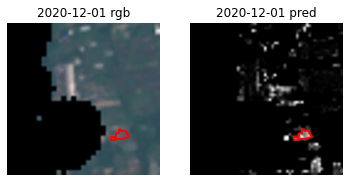

In [381]:
areas = []
monthly_contours = []
dates = []

scale = 4
img_size = rgb_stack[0].shape[0] * scale
for pred, rgb, date in zip(preds_stack, rgb_stack, dates_list):
    #preds = (pred * 255).astype('uint8')
    #pred /= np.max(pred)
    #pred[pred < 0] = 0
    pred = Image.fromarray((pred * 255).astype(np.uint8)).resize((img_size, img_size))
    pred = np.array(pred)
    
    #rgb /= np.max(rgb)
    #rgb[rgb < 0] = 0
    rgb = Image.fromarray((rgb * 255).astype(np.uint8)).resize((img_size, img_size))
    ret, thresh = cv2.threshold(pred, 100, 255, 0)
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    largest_contours = sorted(contours * scale, key=cv2.contourArea)[-3:]
    if largest_contours:
        areas.append(cv2.contourArea(largest_contours[0]))
        monthly_contours.append(largest_contours[0])
        dates.append(date)
    three_channel_preds = np.clip(np.stack((pred, pred, pred), axis=-1), 0, 255)
    preds_contour_img = cv2.drawContours(three_channel_preds, largest_contours, -1, (255,0,0), 2)
    rgb_contour_img = cv2.drawContours(np.array(rgb), largest_contours, -1, (255,0,0), 2)
    plt.subplot(1,2,1)
    plt.title(date + ' rgb')
    plt.imshow(rgb_contour_img, vmax=255, vmin=0)
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(preds_contour_img, vmax=255, vmin=0)
    plt.title(date + ' pred')
    plt.axis('off')
    plt.show()

areas = areas[:-2]

In [378]:
import rasterio as rs
from rasterio import warp
x, y = warp.transform(rs.crs.CRS.from_epsg(4326), rs.crs.CRS.from_epsg(3857), [site_coords[0] - rect_width / 2, 
                                                                               site_coords[0] + rect_width / 2],                                                                      [site_coords[1] - rect_width / 2, 
                                                                               site_coords[1] + rect_width / 2])
width = abs(x[0] - x[1])
height = abs(y[0] - y[1])
area = width * height
num_pixels = rgb.width * rgb.height
pixel_area = area / num_pixels
print("m^2 per pixel:", pixel_area)

m^2 per pixel: 6.163562653066446


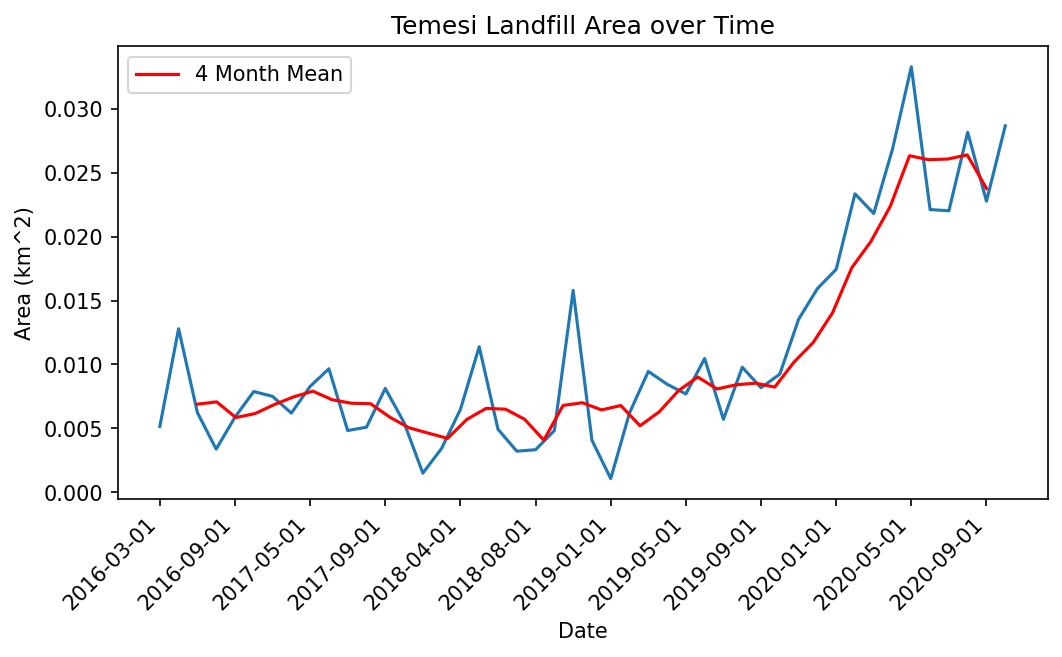

In [376]:
window_size = 4
mean_val = []
for i in range(len(areas) - window_size):
    mean_val.append(np.mean(areas[i:i+window_size]) * pixel_area / 1000000)

plt.figure(figsize=(8,4), facecolor=(1,1,1), dpi=150)
plt.plot(np.array(areas) * pixel_area / 1000000)
plt.plot(np.linspace(window_size / 2, len(areas) - window_size / 2, len(mean_val)), mean_val, c='r', label=f"{window_size} Month Mean")
plt.xticks(range(0, len(preds_stack), window_size), dates_list[0:-1:window_size], ha='right', rotation=45)
plt.title('Temesi Landfill Area over Time')
plt.ylabel('Area (km^2)')
plt.xlabel('Date')
plt.legend()
plt.show()


## Convert Pixel Contours to Coordinate Geojson

In [399]:
import geojson
import json
import datetime
west  = site_coords[0] - rect_width / 2
east  = site_coords[0] + rect_width / 2
north = site_coords[1] + rect_width / 2
south = site_coords[1] - rect_width / 2
width = rgb.width
height = rgb.height
transform = rs.transform.from_bounds(west, south, east, north, width, height)

polygons = []

for contour, date in zip(monthly_contours, dates):
    contour_coords = []
    for point in contour[:,0]:
        lon, lat = rs.transform.xy(transform, point[1], point[0])
        contour_coords.append([lon, lat])
    contour_coords.append(contour_coords[0])
    polygons.append(geojson.Feature(geometry=geojson.Polygon(coordinates = [contour_coords]), properties={'date': datetime.datetime.strptime(date, "%Y-%m-%d").strftime("%Y/%m/%d %H:%M")}))

data_dir = os.path.join('figures/time_series/', name)

json_fc = json.dumps(geojson.FeatureCollection(polygons))
with open(os.path.join(data_dir, name + '_contours.geojson'), 'w') as f:
    f.write(json_fc)

In [398]:
datetime.datetime.strptime(date, "%Y-%m-%d").strftime("%Y/%m/%d %H:%M")

'2020/12/01 00:00'

'2020-12-01'